In [1]:
#gcrsim lvl1 pipeline interface test
import numpy as np
from GCRsim_v02h import CosmicRaySimulation
from electron_spread2 import process_electrons_to_DN_by_blob
from datetime import datetime

def generate_singleframe_cr(rng, nat_pix:int = 4088, date:float = 2026.790, dt:float = 3.04,
                            apply_padding: bool = False, settings_dict = None):
    rng = rng #not sure what our plan was for this rng again?
    
    #create sim object to run gcrs through the detector
    sim = CosmicRaySimulation(grid_size=nat_pix, date=date)
    _,_, trajectory_data, _ = sim.run_full_sim(grid_size=nat_pix, dt=dt, progress_bar=True, apply_padding = apply_padding)
    
    #extract the energy deposition and energy transfer data into a csv file
    current_date = datetime.now()
    computer_friendly_date = current_date.strftime("%Y%m%d%H%M")
    file_name = computer_friendly_date+'_energy_loss.csv'
    output_path = computer_friendly_date+'_outputArray.npy'
    
    sim.build_energy_loss_csv(trajectory_data, file_name)
    
    #send to electron_spread2.py for pixelation (requires having energy deposition csv)
    out_array = process_electrons_to_DN_by_blob(
                    csvfile=file_name,
                    n_pixels = nat_pix,
                    output_array_path=output_path,
                    apply_gain = False)
    
    #assuming no gain in electron_spread2(apply_gain = False)
    #at this point, out_array is in electrons per pixel and size (4088,4088)
    
    return out_array

In [2]:
rng = np.random.default_rng()

out_array_img = generate_singleframe_cr(rng)

Running simulation for each species: 100%|██████████| 85/85 [00:07<00:00, 10.79it/s]


Saved 67967 energy‐loss records to '202510021659_energy_loss.csv'


Processing primary GCRs: 100%|██████████| 160/160 [01:43<00:00,  1.54it/s]

Saved electrons-per-pixel array to 202510021659_outputArray.npy


In [9]:
%matplotlib widget

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle
from scipy import ndimage as ndi

def find_and_mark_objects(
    H,
    threshold=None,          # None => auto: (>0.5 if very sparse; else robust percentile)
    min_size=3,              # minimum pixels per object to keep
    connectivity=2,          # 1=4-connected, 2=8-connected
    boundary_mode="pixels",     # "box" (red rectangles) or "pixels" (exact boundary pixels)
    figsize=(7, 7),
    title="Detected objects",
    save_to=None,            # e.g. "overlay.png"
    return_stats=True,       # returns list of per-object stats if True
):
    """
    H: 2D numpy array (electrons/pixel or DN).
    Draws an overlay with object boundaries in red and returns per-object stats.

    Heuristics for threshold:
      - If array is very sparse, use > 0.5 (good for electrons-per-pixel).
      - Otherwise use a robust percentile-based cutoff.
    """
    A = np.asarray(H)
    if A.ndim != 2:
        raise ValueError("H must be a 2D array.")

    # Clean NaNs/inf
    A = np.where(np.isfinite(A), A, 0.0)

    # ---- Choose a threshold if not provided
    nz = A[A > 0]
    if threshold is None:
        if nz.size == 0:
            thr = np.inf  # nothing to detect
        elif (A == 0).sum() / A.size > 0.90:
            # very sparse: treat as electrons-per-pixel
            thr = 0.5
        else:
            # robust cutoff for DN-like arrays
            p99 = np.percentile(nz, 99.0)
            med = np.median(nz)
            mad = np.median(np.abs(nz - med)) + 1e-12
            thr = max(0.25 * p99, med + 3.0 * mad)
    else:
        thr = float(threshold)

    # ---- Label connected components
    mask = A > thr
    if not mask.any():
        print(f"No pixels above threshold {thr:g}.")
        return [] if return_stats else None

    structure = ndi.generate_binary_structure(2, connectivity)
    labeled, nlab = ndi.label(mask, structure=structure)
    if nlab == 0:
        print(f"No objects found above threshold {thr:g}.")
        return [] if return_stats else None

    # Filter small components
    sizes = ndi.sum(mask, labeled, index=np.arange(1, nlab + 1))
    keep_labels = [i + 1 for i, s in enumerate(sizes) if s >= min_size]
    if not keep_labels:
        print("Only tiny speckles found; increase min_size or lower threshold.")
        return [] if return_stats else None

    # ---- Prepare figure
    fig, ax = plt.subplots(figsize=figsize)
    # Nice visualization for sparse images
    masked = np.ma.masked_equal(A, 0)
    if masked.count() > 0:
        vmin = float(masked.min())
        vmax = float(masked.max())
    else:
        vmin = vmax = 1.0
    use_lognorm = (vmin > 0) and (vmax / max(vmin, 1e-9) > 10)
    norm = LogNorm(vmin=max(vmin, 1e-3), vmax=vmax) if use_lognorm else None

    im = ax.imshow(masked, origin="lower", cmap="gray", norm=norm)
    im.cmap.set_bad("black")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(title)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Signal (electrons or DN)")

    # ---- Draw boundaries + collect stats
    obj_slices = ndi.find_objects(labeled)
    stats = []
    for lab in keep_labels:
        sl = obj_slices[lab - 1]
        if sl is None:
            continue
        y0, y1 = sl[0].start, sl[0].stop
        x0, x1 = sl[1].start, sl[1].stop
        h, w = y1 - y0, x1 - x0

        # exact boundary (optional)
        if boundary_mode == "pixels":
            obj_mask = (labeled[y0:y1, x0:x1] == lab)
            eroded = ndi.binary_erosion(obj_mask, structure=structure, border_value=0)
            boundary = obj_mask & (~eroded)
            by, bx = np.where(boundary)
            ax.plot(x0 + bx, y0 + by, ".", ms=1.5, color="red", alpha=0.9, zorder=5)
        else:
            # simple red rectangle
            ax.add_patch(Rectangle((x0, y0), w, h, fill=False, ec="red", lw=1.8, zorder=5))

        # label ID at center
        ax.text(x0 + w / 2, y0 + h / 2, str(lab), color="red",
                ha="center", va="center", fontsize=8, zorder=6)

        # stats
        sub = A[y0:y1, x0:x1]
        stats.append({
            "label": int(lab),
            "x0": int(x0), "y0": int(y0), "width": int(w), "height": int(h),
            "area_px": int(sizes[lab - 1]),
            "sum_signal": float(sub[labeled[y0:y1, x0:x1] == lab].sum()),
            "peak_signal": float(sub.max())
        })

    if save_to:
        fig.savefig(save_to, dpi=150)
        print(f"Saved overlay to {save_to}")

    plt.show()
    return stats if return_stats else None


Saved overlay to detections_overlay.png


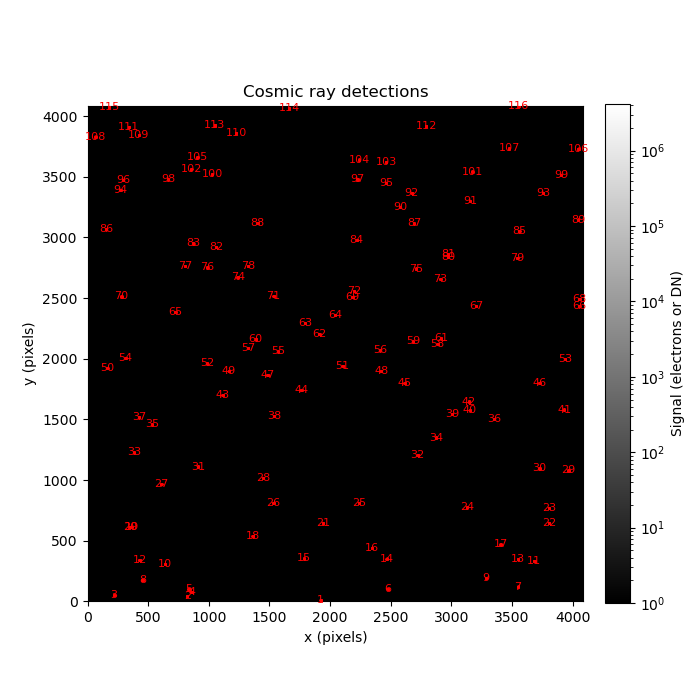

Found 116 objects
{'label': 1, 'x0': 1920, 'y0': 8, 'width': 4, 'height': 4, 'area_px': 14, 'sum_signal': 11740.0, 'peak_signal': 5741.0}
{'label': 2, 'x0': 820, 'y0': 42, 'width': 4, 'height': 4, 'area_px': 13, 'sum_signal': 8507.0, 'peak_signal': 3358.0}
{'label': 3, 'x0': 214, 'y0': 53, 'width': 4, 'height': 4, 'area_px': 16, 'sum_signal': 26146.0, 'peak_signal': 11178.0}
{'label': 4, 'x0': 856, 'y0': 74, 'width': 6, 'height': 4, 'area_px': 20, 'sum_signal': 26808.0, 'peak_signal': 8703.0}
{'label': 5, 'x0': 831, 'y0': 98, 'width': 10, 'height': 7, 'area_px': 42, 'sum_signal': 231051.0, 'peak_signal': 96988.0}


In [11]:

stats = find_and_mark_objects(
    out_array_img,
    threshold=None,       # auto (good default)
    min_size=3,           # ignore 1–2 px speckles
    boundary_mode="pixels",  # or "pixels" for exact outlines
    title="Cosmic ray detections",
    save_to="detections_overlay.png"
)
print(f"Found {len(stats)} objects")
for s in stats[:5]:
    print(s)
